In [2]:
import numpy as np
from matplotlib import pyplot as plt

Wt = np.array([9.8,19.9,29.7,39.9,49.9,59.8,69.9,79.8,89.9,99.8,159.7,319.7])#in gm
z = np.array([3.12,2.50,2.35,2.07,1.91,1.80,1.76,1.52,1.50,1.43,1.13,1.00])#in cm

def Magnetisation(Force,Radius,z,h):
    mu_0 = np.pi*4e-07
    l = (z**-2) + (z+2*h)**-2 -2/(z+h)**2
    M = np.sqrt(((4*Force)/((np.pi*mu_0)*(l*Radius**4))))
    return M

h = 6.4 * 0.001 #in m
z = z * 0.01 #converted in m
Force = Wt*0.001*9.8 #scaled up force with coefficient g and converted to kg
Radius = (12.7/2)*0.001 #converted into m
M = Magnetisation(Force,Radius,z,h)

for i in range(0,12):
    print(f"{M[i]:.4f}")



680750.0892
669185.4328
738507.1205
697006.2502
685713.0880
683709.6896
713664.5653
608292.6582
632773.6336
620243.8859
554732.8025
659597.5759


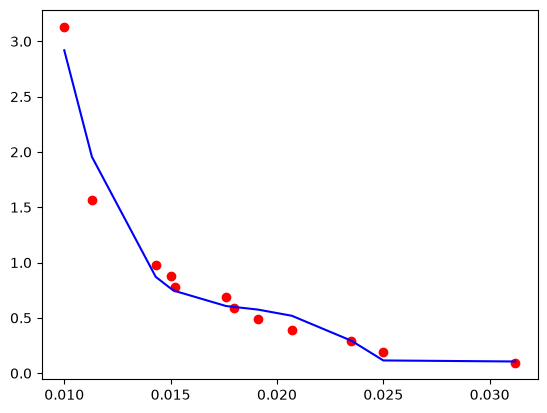

In [3]:
# graph between F vs Z
# Error propagation with least count

#Graph Between F vs Z
plt.scatter(z, Force, color = 'red')
a,b,c,d,e = np.polyfit(z,Force,4)
trendline = a*(z**4)+ b*(z**3)+ c*(z**2) + d*z + e
plt.plot(z, trendline, color = 'blue')

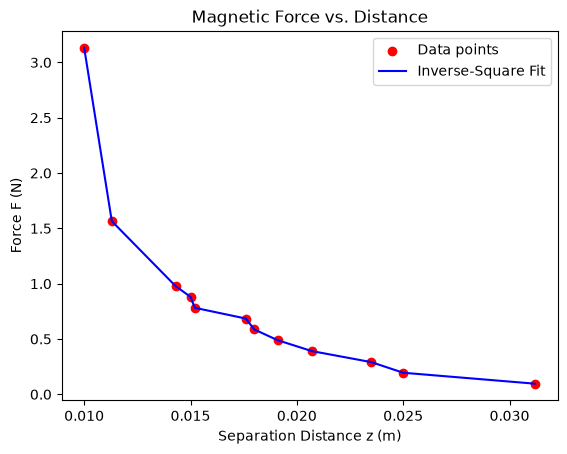

In [4]:
# graph between F vs Z
# Error propagation with least count

#Graph Between F vs Z
plt.scatter(z, Force, color = 'red', label='Data points')
plt.plot(z, Force, color = 'blue', label='Inverse-Square Fit')
plt.xlabel('Separation Distance z (m)')
plt.ylabel('Force F (N)')
plt.title('Magnetic Force vs. Distance')
plt.legend()
plt.show()

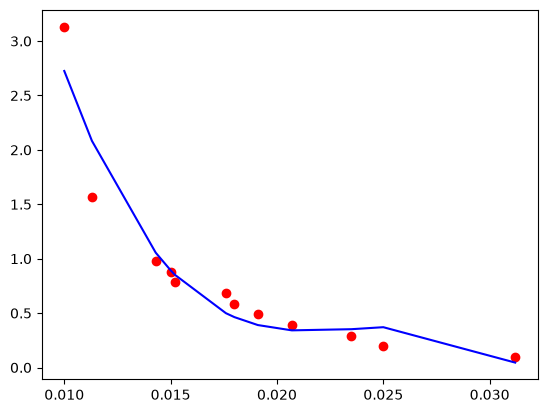

In [5]:
# graph between F vs Z
# Error propagation with least count

#Graph Between F vs Z
plt.scatter(z, Force, color = 'red')
a,b,c,d = np.polyfit(z,Force,3)
trendline = a*(z**3)+ b*(z**2) + c*z + d
plt.plot(z, trendline, color = 'blue')

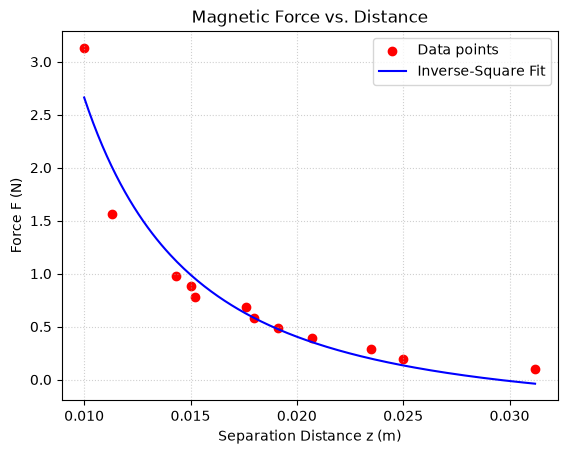

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fit Force vs 1/(z**2)
poly = np.polyfit(1 / (z**2), Force, 1)  # poly[0] is slope, poly[1] is intercept

# 2. Generate smooth x-axis values for plotting
z_smooth = np.linspace(min(z), max(z), 200)
trendline = poly[0] * (1 / (z_smooth**2)) + poly[1]

# 3. Plot
plt.scatter(z, Force, color='red', label='Data points')
plt.plot(z_smooth, trendline, color='blue', label='Inverse-Square Fit')

plt.xlabel('Separation Distance z (m)')
plt.ylabel('Force F (N)')
plt.title('Magnetic Force vs. Distance')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [7]:
#Error Propagation with Least counts
#We will combine Statistical and Least count errors via del(x) = sqrt(std_err_sts^2(x)+least_count(x)^2)

del_F = 0.00098 #0.1e-03*9.8
del_z = 0.00002 #2e-05


def M_err(F,h,z,R,del_z,del_F):
    l1 = z**-2 + -2*(z+h)**-2 + (z+2*h)**-2 
    l2 = z**-3 + -2*(z+h)**-3 +(z+2*h)**-3
    C1 = ((4)/((np.pi**2*4e-7)*R**4*l1))
    C2 = ((F*4)/((np.pi**2*4e-7)*R**4))
    C3 = np.sqrt(C1/(4*F))
    C4 = np.sqrt(C2)*l1**(-3/2)*l2
    M = np.sqrt((del_F*C3)**2 + ((del_z*C4)**2))
    return M

print("Error in M is ", M_err(Force,h,z,Radius,del_z,del_F))

Error in M is  [3551.64733774 1899.32992222 1613.07255565 1388.84848755 1327.96917025
 1320.63180585 1365.1028547  1276.14507841 1328.23109016 1341.96825234
 1424.25470349 1857.63888813]


In [8]:
import pandas as pd
Data  = {
    "Mass(in grams)" : [9.8,19.9,29.7,39.9,49.9,59.8,69.9,79.8,89.9,99.8,159.7,319.7],
    "z(gap)(in cm)" : [3.12,2.50,2.35,2.07,1.91,1.80,1.76,1.52,1.50,1.43,1.13,1.00]
}

df = pd.DataFrame(Data)
print(df)


    Mass(in grams)  z(gap)(in cm)
0              9.8           3.12
1             19.9           2.50
2             29.7           2.35
3             39.9           2.07
4             49.9           1.91
5             59.8           1.80
6             69.9           1.76
7             79.8           1.52
8             89.9           1.50
9             99.8           1.43
10           159.7           1.13
11           319.7           1.00
